In [1]:
import os
import pickle
from collections import Counter
from typing import Dict, List, Tuple, FrozenSet

In [2]:
DIR = "../case_study/T_cell/N10/results/20260616/"

In [3]:
PI = Dict[str, int]
NodePIs = List[List[PI]]  # [inactivation, activation]
Networks = List[Dict[str, NodePIs]]

In [4]:
def canon_pi(pi: PI) -> FrozenSet[Tuple[str, int]]:
    return frozenset(pi.items())


def canon_node(node_pis: NodePIs):
    """
    Full node rule:
    (inactivation set, activation set)
    """
    inact = frozenset(canon_pi(pi) for pi in node_pis[0])
    act = frozenset(canon_pi(pi) for pi in node_pis[1])
    return (inact, act)

In [5]:
def split_nodes(networks: Networks):
    nodes = networks[0].keys()

    node_versions = {node: [] for node in nodes}

    for net in networks:
        for node in nodes:
            node_versions[node].append(canon_node(net[node]))

    invariant_nodes = {}
    variable_nodes = {}

    for node, versions in node_versions.items():
        first = versions[0]

        if all(v == first for v in versions):
            invariant_nodes[node] = networks[0][node]
        else:
            variable_nodes[node] = versions

    return invariant_nodes, variable_nodes

In [6]:
def consensus_from_variable_nodes(variable_nodes, threshold: float, n_networks: int):
    result = {}

    for node, versions in variable_nodes.items():
        inact_counter = Counter()
        act_counter = Counter()

        for (inact_set, act_set) in versions:
            inact_counter.update(inact_set)
            act_counter.update(act_set)

        def filter(counter: Counter):
            return [
                dict(pi)
                for pi, count in counter.items()
                if (count / n_networks) >= threshold
            ]

        result[node] = [
            filter(inact_counter),
            filter(act_counter),
        ]

    return result

In [7]:
def build_consensus(networks: Networks, threshold: float = 1.0):
    n_networks = len(networks)

    invariant, variable = split_nodes(networks)

    consensus = consensus_from_variable_nodes(variable, threshold, n_networks)

    return {
        "consensus": consensus,
        "invariant_nodes": invariant
    }

In [8]:
# primes1 = pickle.load(open("../case_study/T_cell/Tcell_primes.pkl", "rb"))
# primes2 = pickle.load(open("../case_study/T_cell/generated_models/20260613_1/Tcell_4405_gen28_primes.pkl", "rb"))
# networks = [primes1, primes2]

In [9]:
# read all pickle files in a target directory
directory = os.listdir(DIR)


networks = []
for filename in directory:
    if filename.endswith(".pkl"):
        primes = pickle.load(open(os.path.join(DIR, filename), "rb"))
        networks.append(primes)

print(len(networks))

66


In [10]:
consensus = build_consensus(networks)
consensus

{'consensus': {'FOXP3': [[], []],
  'GATA3': [[{'STAT6': 0, 'GATA3': 0}], [{'TBET': 0, 'STAT6': 1}]],
  'IFNG': [[], []],
  'IL10': [[], []],
  'IL17': [[], []],
  'IL2': [[], []],
  'IL23': [[{'NFAT': 0}], []],
  'IL23R': [[{'STAT3': 0}, {'IL23': 0, 'IL23_e': 0}],
   [{'IL23': 1, 'STAT3': 1, 'RORGT': 1},
    {'IL23_e': 1, 'RORGT': 1, 'STAT3': 1}]],
  'IL2R': [[], []],
  'IL2RA': [[], []],
  'IL4': [[{'NFAT': 0}, {'IRF1': 1}, {'RUNX3': 1, 'TBET': 1}],
   [{'TBET': 0,
     'IRF1': 0,
     'NFAT': 1,
     'FOXP3': 0,
     'proliferation': 1,
     'GATA3': 1}]],
  'IL4R': [[{'IL4R_2': 0, 'IL4_e': 0, 'IL4': 0}], [{'IL4_e': 1}, {'IL4': 1}]],
  'IL4RA_2': [[{'STAT5_2': 0}], []],
  'IL4R_2': [[{'IL4R': 0}], []],
  'STAT3': [[], []],
  'STAT4': [[], []],
  'STAT5': [[], []],
  'STAT5_2': [[{'STAT5': 0}], []],
  'TBET': [[], []],
  'TGFB': [[{'FOXP3': 0}], []],
  'proliferation': [[{'proliferation': 0, 'STAT5': 0}],
   [{'proliferation': 1}]]},
 'invariant_nodes': {'APC': [[{'APC': 0}], [{'APC'

In [11]:
invariant_nodes = list(consensus["invariant_nodes"].keys())
variable_nodes = list(consensus["consensus"].keys())

print(f"{len(invariant_nodes)} invariant nodes:", list(consensus["invariant_nodes"].keys()))
print(f"{len(variable_nodes)} variable nodes:", list(consensus["consensus"].keys()))

37 invariant nodes: ['APC', 'CD28', 'IFNBR', 'IFNB_e', 'IFNGR', 'IFNG_e', 'IKB', 'IL10R', 'IL10_e', 'IL12R', 'IL12RB1_2', 'IL12RB2', 'IL12_e', 'IL15R', 'IL15_e', 'IL21', 'IL21R', 'IL21_e', 'IL23_e', 'IL27R', 'IL27_e', 'IL2R_2', 'IL2_e', 'IL4_e', 'IL6R', 'IL6_e', 'IRF1', 'NFAT', 'NFKB', 'RORGT', 'RUNX3', 'SMAD3', 'STAT1', 'STAT6', 'TCR', 'TGFBR', 'TGFB_e']
21 variable nodes: ['FOXP3', 'GATA3', 'IFNG', 'IL10', 'IL17', 'IL2', 'IL23', 'IL23R', 'IL2R', 'IL2RA', 'IL4', 'IL4R', 'IL4RA_2', 'IL4R_2', 'STAT3', 'STAT4', 'STAT5', 'STAT5_2', 'TBET', 'TGFB', 'proliferation']


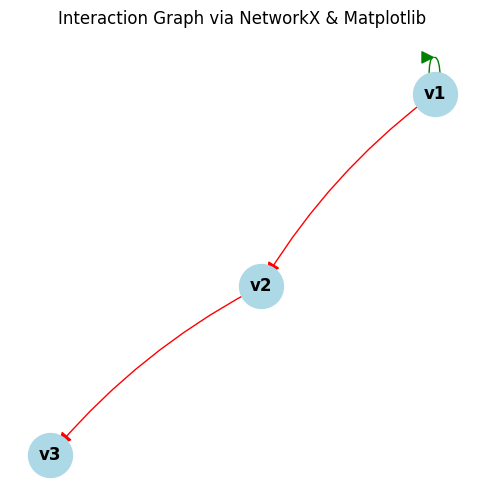

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
from pyboolnet.interaction_graphs import primes2igraph

# 1. PLUG IN YOUR PRIMES DICTIONARY HERE
# (This example represents: v1 = !v1, v2 = v1, v3 = v1 or !v2)
primes = {
    "v1": [[{"v1": 0}], [{"v1": 1}]],
    "v2": [[{"v1": 1}], [{"v1": 0}]],
    "v3": [[{"v2": 1}], [{"v2": 0}]]
}

# 2. Generate the NetworkX directed graph object
igraph = primes2igraph(primes)

# 3. Setup the Matplotlib canvas
plt.figure(figsize=(6, 6))

# Calculate node layout positions (spring layout spaces them out nicely)
pos = nx.spring_layout(igraph, seed=42)

# 4. Separate edges by their PyBoolNet interaction sign for distinct coloring
edge_colors = []
for u, v, d in igraph.edges(data=True):
    sign_set = d.get("sign", set())
    if 1 in sign_set and -1 in sign_set:
        edge_colors.append("orange")  # Ambivalent / Dual interaction
    elif 1 in sign_set:
        edge_colors.append("green")  # Activation
    elif -1 in sign_set:
        edge_colors.append("red")  # Inhibition
    else:
        edge_colors.append("black")  # Unknown / Default

# 5. Draw the graph components natively
nx.draw_networkx_nodes(igraph, pos, node_size=1000, node_color="lightblue")
nx.draw_networkx_labels(igraph, pos, font_size=12, font_weight="bold")
nx.draw_networkx_edges(
    igraph,
    pos,
    edge_color=edge_colors,
    arrowsize=20,
    connectionstyle="arc3,rad=0.1",  # Slight bend prevents overlapping bidirectional edges
)

plt.title("Interaction Graph via NetworkX & Matplotlib")
plt.axis("off")
plt.show()